# Libs preparation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data preparation

In [3]:
train_df = pd.read_csv("../data/raw/train.csv")
test_df = pd.read_csv("../data/raw/test.csv")

In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  str    
 3   Customer Type                      103904 non-null  str    
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  str    
 6   Class                              103904 non-null  str    
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      103904 non-null

In [5]:
train_df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


# EDA

In [6]:
train_df.duplicated().sum()

np.int64(0)

In [7]:
train_df["satisfaction"].value_counts(normalize=True)*100

satisfaction
neutral or dissatisfied    56.666731
satisfied                  43.333269
Name: proportion, dtype: float64

- Note: ở đây target không bị quá chênh lệch quá nhiều

"sẽ tìm references chứng minh sau" 

## Onehot endcoding

In [8]:
eda_df = train_df.copy()

In [9]:
eda_df = eda_df.drop(columns = ["Unnamed: 0", "id"])
eda_df["Type of Travel"] = eda_df["Type of Travel"].map({"Business travel": 1, "Personal Travel": 0})
eda_df["Class"] = eda_df["Class"].map({"Business": 2, "Eco": 0, "Eco Plus": 1})
eda_df["Gender"] = eda_df["Gender"].map({"Male": 1, "Female": 0})
eda_df["Customer Type"] = eda_df["Customer Type"].map({"Loyal Customer": 1, "disloyal Customer": 0})
eda_df["satisfaction"] = eda_df["satisfaction"].map({"satisfied": 1, "neutral or dissatisfied": 0})

eda_df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,1,13,0,1,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,1,0,25,1,2,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,0,1,26,1,2,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,0,1,25,1,2,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,1,1,61,1,2,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


In [10]:
eda_df.describe()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,...,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000,103904.000000
mean,0.492541,0.817322,39.379706,0.689627,1.028103,1189.448375,2.729683,3.060296,2.756901,2.976883,...,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678,0.433333
std,0.499947,0.386404,15.114964,0.462649,0.962858,997.147281,1.327829,1.525075,1.398929,1.277621,...,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682,0.495538
min,0.000000,0.000000,7.000000,0.000000,0.000000,31.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,27.000000,0.000000,0.000000,414.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,40.000000,1.000000,1.000000,843.000000,3.000000,3.000000,3.000000,3.000000,...,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,51.000000,1.000000,2.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000,1.000000
max,1.000000,1.000000,85.000000,1.000000,2.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000,1.000000


In [48]:
import os

print(os.getcwd())

/Users/phamvantruong/Documents/AIO 2026/Conquer/AIO_Conquer_module03/AIO2026-Conquer3-Redteam/notebooks


In [ ]:
eda_df.to_csv("../data/processed/eda_df.csv", index=False)
# trích xuất file dữ liệu đã được xử lý từ thư mục processed để sử dụng cho các bước tiếp theo trong quá trình phân tích dữ liệu và xây dựng mô hình.

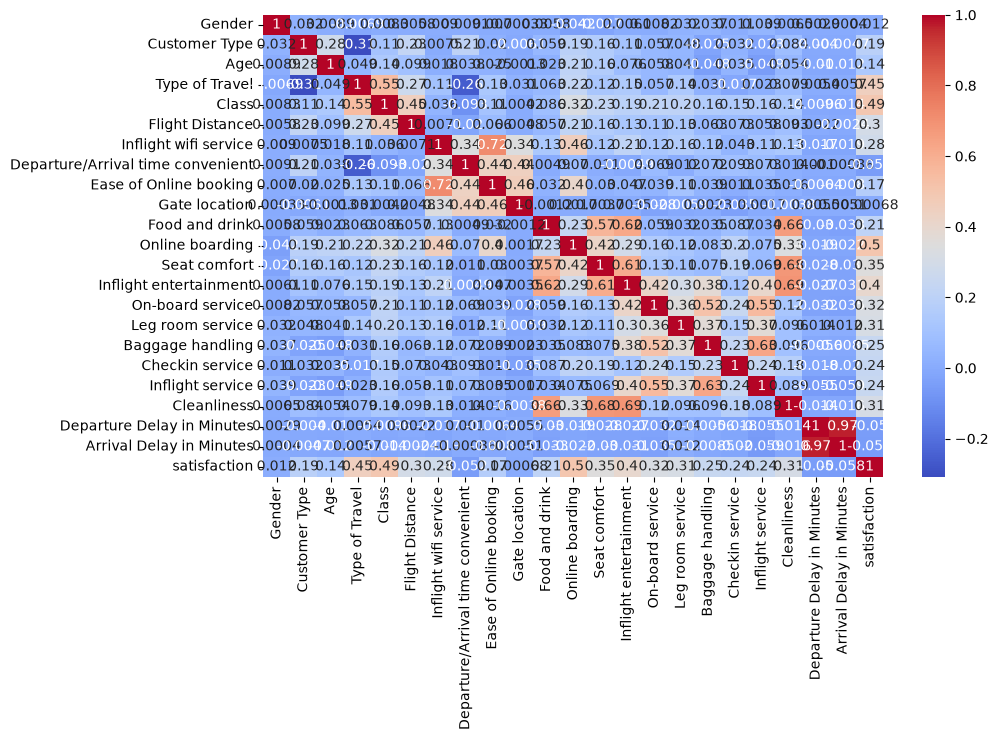

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(eda_df.select_dtypes(include=[np.number]).corr(), annot=True, cmap="coolwarm")

plt.show()

NOTE: 
- Cặp Departure delay và Arrival delay có tương quan rất cao => vì xuất phát trễ dẫn đến đáp trễ, khi đưa vào mô hình thì nên cân nhắc về vấn đề đa cộng tuyến

Phân tích theo nhóm feature, từ đó trực quan hoá theo các nhóm features với sự hài lòng của khách hàng.

Các nhóm features chúng ta có thể gom lại như sau:

- Target: satisfication
- Demographic: Gender, Age, Customer Type
- Travel characteristics: Type of Travel, Class, Flight Distance
- Service rattings: Inflight wifi service, Departure/ Arrival time, Ease of online booking, gate location...
- Operational: Departures time, Arrival time

Analyst goals:
- what are impact on target?
- How are influence?


In [12]:
gender_satisfaction = pd.crosstab(
    train_df["Gender"],
    train_df["satisfaction"],
    normalize="index" # mỗi hàng cộng lại thành 100%
) * 100

gender_satisfaction

satisfaction,neutral or dissatisfied,satisfied
Gender,,
Female,57.262882,42.737118
Male,56.052524,43.947476


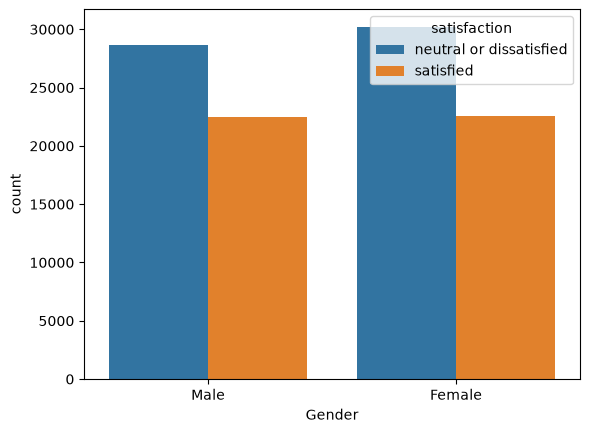

In [13]:
sns.countplot(data = train_df, x = "Gender", hue = "satisfaction")
plt.show()

Giới tính và việc có hài lòng không nó chỉ lệch một số rất nhỏ.

Với những sample hài lòng thì giữa nam với nữ chỉ khoảng 1,2% => gender có vẻ ít liên quan đến target đang muốn dự đoán

In [14]:
train_df["Age"].describe()

count    103904.000000
mean         39.379706
std          15.114964
min           7.000000
25%          27.000000
50%          40.000000
75%          51.000000
max          85.000000
Name: Age, dtype: float64

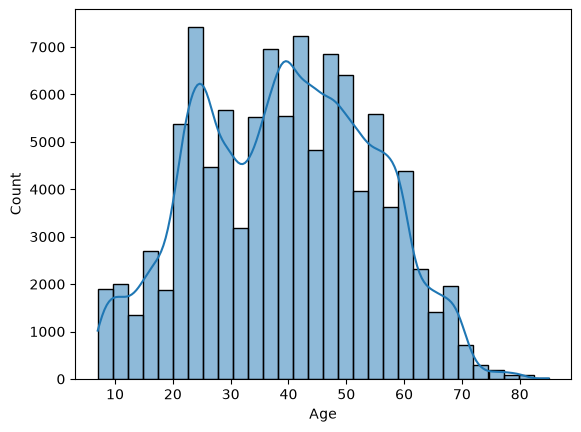

In [15]:
sns.histplot(data=train_df, x="Age", bins=30,kde=True)
plt.show()

1. Ta thấy số lượng hành khách thay đổi khá nhiều giữa các nhóm tuổi. Có những vùng cao rõ rệt, đặc biệt khoảng 20–25 và 35–50 tuổi, trong khi hai đầu phân phối có ít người hơn.

2. Nhóm độ tuổi dưới 18 thấp hơn nhiều so với nhóm trưởng thành

3. Tập trung chủ yếu ở nhóm 20-60 tuổi

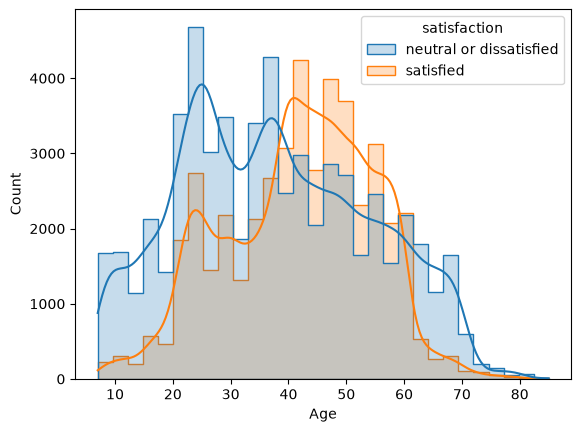

In [16]:
sns.histplot(data= train_df, x="Age", hue="satisfaction", bins=30, kde=True, element="step")
plt.show()

1. Nhóm 35–55 tuổi có xu hướng hài lòng cao hơn: đường satisfied nhìn chung vượt neutral or dissatisfied trong vùng này. Đây thường là nhóm khách đi làm/công tác, có khả năng sử dụng các hạng dịch vụ cao hơn và coi trọng sự tiện lợi, đúng giờ, dịch vụ trên chuyến bay.

2. Nhóm trẻ khoảng 20–30 tuổi có tỷ lệ không hài lòng nổi bật: neutral or dissatisfied cao hơn khá rõ. Một giả thuyết nghiệp vụ hợp lý là khách trẻ có kỳ vọng cao hơn với wifi, online booking, entertainment và trải nghiệm số, nên các điểm yếu ở những dịch vụ này có thể ảnh hưởng mạnh đến satisfaction.

3. Hành khách dưới ~20 tuổi chủ yếu nằm ở nhóm không hài lòng/neutral, nhưng cần cẩn thận khi diễn giải vì số lượng hành khách trẻ trong dataset tương đối thấp và trải nghiệm của trẻ em có thể gắn với chuyến đi gia đình hơn là quyết định dịch vụ độc lập.

4. Sau khoảng 60 tuổi, mức satisfied giảm mạnh, nhưng đồng thời tổng số hành khách cũng giảm. Vì vậy chưa nên kết luận rằng người lớn tuổi ít hài lòng hơn chỉ dựa vào count.

5. Age có vẻ có mối quan hệ với satisfaction, nhưng không tuyến tính. Không phải cứ tuổi tăng thì satisfaction tăng; pattern giống kiểu: thấp ở nhóm trẻ cao hơn ở trung niên giảm ở nhóm lớn tuổi.

6. Business implication: hãng hàng không có thể cần phân khúc khách hàng theo độ tuổi thay vì áp dụng một trải nghiệm giống nhau cho tất cả. Tuy nhiên, trước khi đưa ra quyết định, nên kiểm tra thêm Age × Type of Travel, age × class, age × wifi service... vì age có thể chỉ là proxy cho hành vi du lịch.

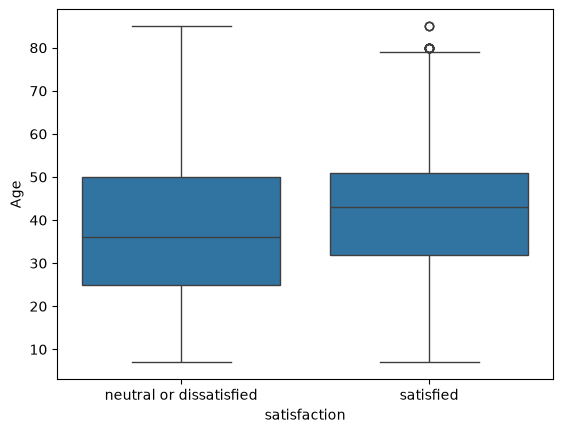

In [17]:
sns.boxplot(data=train_df, x="satisfaction", y="Age")
plt.show()

Nếu cần có thể phân tích mở rộng Gender x Age

### 2.1 Customer type

In [18]:
customer_sat = pd.crosstab(
    train_df["Customer Type"],
    train_df["satisfaction"],
    normalize="index"
) * 100

customer_sat

satisfaction,neutral or dissatisfied,satisfied
Customer Type,,
Loyal Customer,52.270881,47.729119
disloyal Customer,76.334229,23.665771


1. Loyal customers có satisfaction rate cao hơn đáng kể: khoảng 47.7% khách hàng trung thành hài lòng, so với chỉ 23.7% ở disloyal customers.

2. Khoảng cách satisfaction rate là 24 percentage points (47.7% - 23.7%) khác biệt này khá lớn về mặt mô tả.

3. Disloyal customers có mức không hài lòng rất cao: khoảng 76.3% thuộc nhóm neutral or dissatisfied. Đây là một pattern đáng chú ý trong EDA.

4. loyal customers có thể là frequent flyers hoặc thành viên chương trình loyalty. Họ có thể quen với hãng, nhận được các benefits như priority services, upgrades, lounge access, mileage rewards... nên trải nghiệm tổng thể có thể tốt hơn. Ngược lại, disloyal customers có thể nhạy cảm hơn với giá và trải nghiệm của từng chuyến bay, đồng thời ít nhận được loyalty benefits nên có thể góp phần vào satisfaction thấp hơn.

=> Customer Type có vẻ là một feature liên quan khá mạnh đến satisfaction và đáng được chú ý khi modeling.

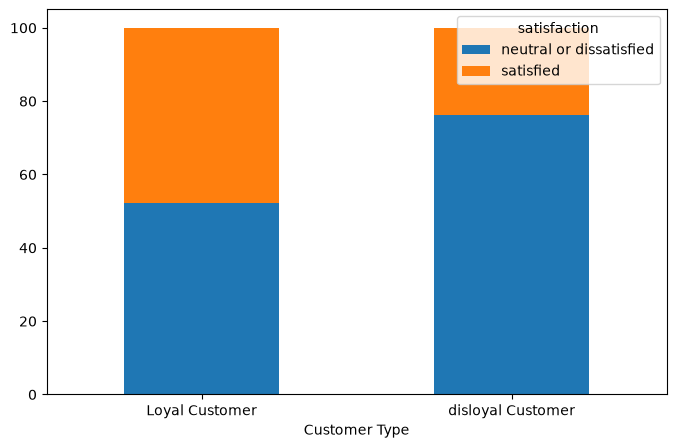

In [19]:
customer_sat.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.xticks(rotation=0)

plt.show()

### 2.2 Type of travel

In [20]:
travel_sat = pd.crosstab(train_df["Type of Travel"], train_df["satisfaction"], normalize="index") * 100

travel_sat

satisfaction,neutral or dissatisfied,satisfied
Type of Travel,,
Business travel,41.740283,58.259717
Personal Travel,89.832243,10.167757


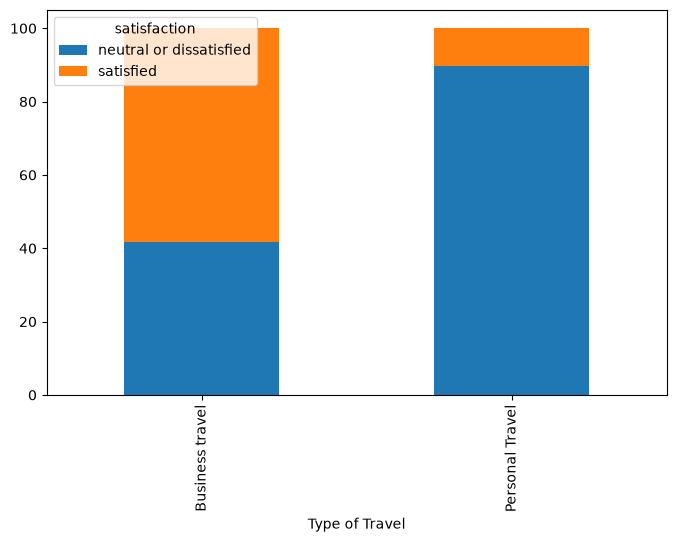

In [69]:
travel_sat.plot(kind="bar", stacked=True, figsize=(8, 5))

plt.show()

1. Business travelers có satisfaction rate khá cao: khoảng 58.3% satisfied, cao hơn tỷ lệ neutral/dissatisfied (41.7%).

2. Ngược lại, Personal Travel có mức không hài lòng cực kỳ cao: gần 89.8% neutral/dissatisfied, chỉ khoảng 10.2% satisfied.

3. Chênh lệch satisfaction rate giữa hai nhóm lên tới khoảng 48.1 percentage points (58.3% − 10.2%). Đây là một sự khác biệt rất lớn về mặt descriptive analysis.

4. Type of Travel vì vậy có vẻ là một strong signal cho satisfaction.

=> Business travelers có thể thường sử dụng Business Class, loyalty programs, priority services hoặc các dịch vụ tiện lợi hơn, trong khi Personal travelers có thể sử dụng Economy nhiều hơn và nhạy cảm hơn với giá, sự thoải mái hoặc thời gian chuyến bay. Tuy nhiên đây mới là giả thuyết để kiểm tra, chưa phải kết luận từ biểu đồ.

### 2.3 Class

In [21]:
class_sat = pd.crosstab(train_df["Class"], train_df["satisfaction"], normalize="index") * 100

class_sat

satisfaction,neutral or dissatisfied,satisfied
Class,,
Business,30.574852,69.425148
Eco,81.386245,18.613755
Eco Plus,75.393648,24.606352


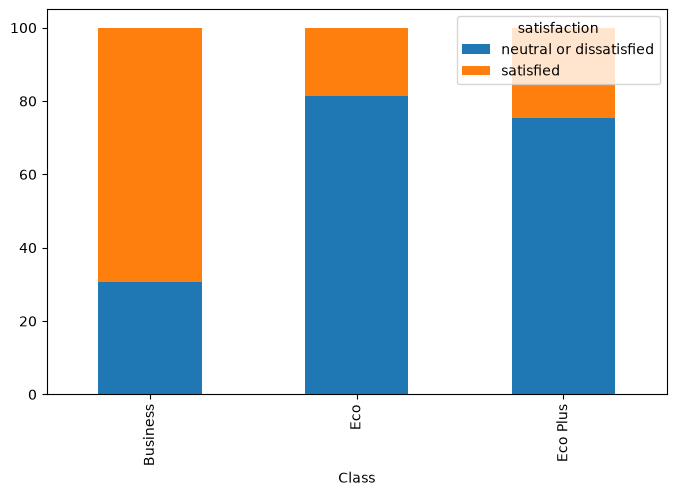

In [22]:
class_sat.plot(kind = "bar", stacked = True, figsize=(8, 5))

plt.show()

1. Business Class có satisfaction rate cao vượt trội: khoảng 69.4% satisfied, trong khi chỉ 30.6% neutral/dissatisfied. Số hành khách hài lòng chiếm đa số.

2. Economy Class có satisfaction thấp nhất: chỉ khoảng 18.6% satisfied, tương đương hơn 81% neutral/dissatisfied.

3. Eco Plus tốt hơn Economy một chút: satisfaction rate khoảng 24.6%, cao hơn Eco khoảng 6 percentage points, nhưng vẫn thấp hơn Business rất nhiều.

4. Khoảng cách Business vs Economy cực lớn: 69.4% − 18.6% ~ 50.8 percentage points. => Class có vẻ là một strong signal đối với satisfaction.

Điều này khá hợp lý vì Business Class thường đi kèm trải nghiệm tốt hơn như ghế rộng và thoải mái hơn, priority check-in/boarding, dịch vụ ăn uống tốt hơn, nhiều không gian cá nhân hơn và mức độ phục vụ cao hơn. Những yếu tố đó đều có khả năng liên quan đến satisfaction.
Tuy nhiên, không nên kết luận Class => Satisfaction theo quan hệ nhân quả. Class có thể liên quan chặt với Type of Travel và Customer Type. Ví dụ, business travelers có thể xuất hiện trong Business Class nhiều hơn.

### 2.4 Flight Distance

In [23]:
train_df["Flight Distance"].describe()

count    103904.000000
mean       1189.448375
std         997.147281
min          31.000000
25%         414.000000
50%         843.000000
75%        1743.000000
max        4983.000000
Name: Flight Distance, dtype: float64

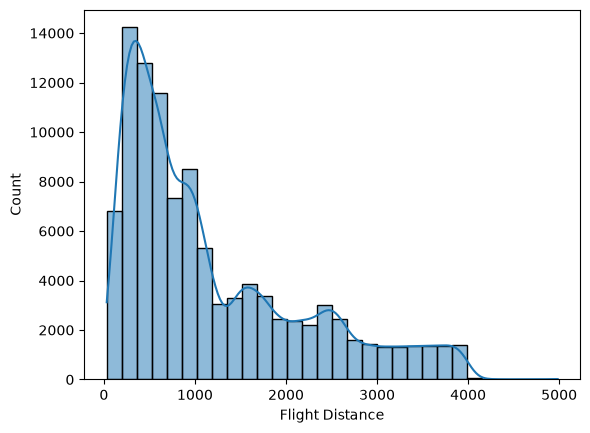

In [25]:
sns.histplot(data= train_df, x="Flight Distance", bins=30, kde=True)
plt.show()


Phần lớn các chuyến bay đều tập trung ở khoảng cách tương đối ngắn, chủ yếu khách hàng di chuyển <1,000 (Phân phối lệch phải), có một nhóm đáng kể ở khoản từ 1,500-2,500 và tạo thành một đuôi kéo dài tới khoảng 4,000 hơn.




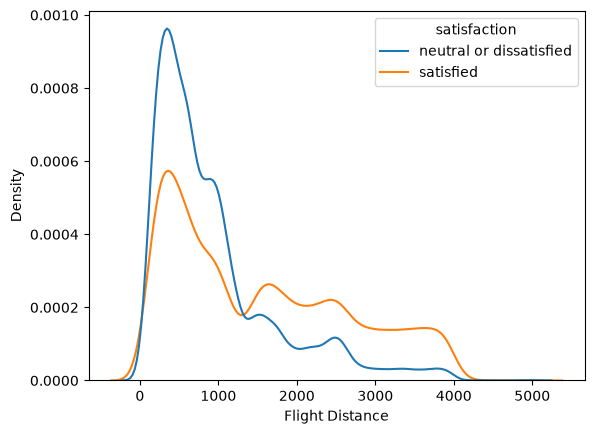

In [26]:
sns.kdeplot(data = train_df, x = "Flight Distance", hue = "satisfaction", common_norm = False)
plt.show()

Nhóm neutral or dissatisfied tập trung nhiều nhất ở khu vực các chuyến bay có cự ly ngắn, bay nhanh.

Khi distance tăng lên, pattern nổi trội hơn lại thuộc về nhóm satisfied. => chuyến bay dài khách hàng có xu hướng hài lòng nhiều hơn. 

Ở trên, với correlation matrix chúng ta cũng có thể thấy được Flight Distance có tương quan dương với satisfaction ~ 0.3 khá nhẹ.

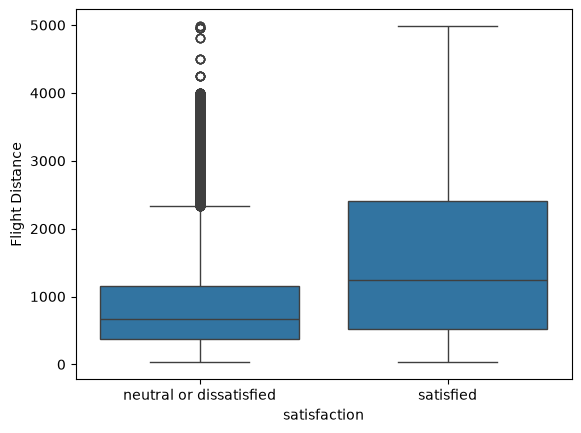

In [27]:
sns.boxplot(data = train_df, x = "satisfaction", y = "Flight Distance")
plt.show()

Nhóm satisfied có mức độn phân tán rộng hơn, cho thấy sự hài lòng xuất hiện ở nhiều chuyến bay với mức khoảng cách đa dạng.

### 2.5 Interaction

Class x Type of Travel

In [29]:
interac_sat = pd.crosstab([train_df["Class"], train_df["Type of Travel"]], train_df["satisfaction"], normalize="index") * 100
interac_sat

satisfaction              neutral or dissatisfied  satisfied
Class    Type of Travel                                     
Business Business travel                27.978446  72.021554
         Personal Travel                87.760779  12.239221
Eco      Business travel                70.380609  29.619391
         Personal Travel                89.802930  10.197070
Eco Plus Business travel                60.668380  39.331620
         Personal Travel                91.287458   8.712542

1. Business Travel luôn có satisfaction cao hơn Personal Travel trong cùng một Class.
    - Business Class: 72.0% vs 12.2%
    - Eco: 29.6% vs 10.2%
    - Eco Plus: 39.3% vs 8.7%

2. Class vẫn có ảnh hưởng rõ trong nhóm Business Travel: Business Class (72%) > Eco Plus (39.3%) > Eco (29.6%).

3. Đặc biệt, Personal Travel có satisfaction rất thấp ở tất cả các Class (~9–12%) => Type of Travel có vẻ là một signal rất mạnh.

Điều này trả lời câu hỏi lúc trước: Business travelers không chỉ hài lòng hơn vì họ đi Business Class. Ngay cả khi cùng Eco hoặc Eco Plus, Business Travel vẫn có satisfaction cao hơn Personal Travel đáng kể.

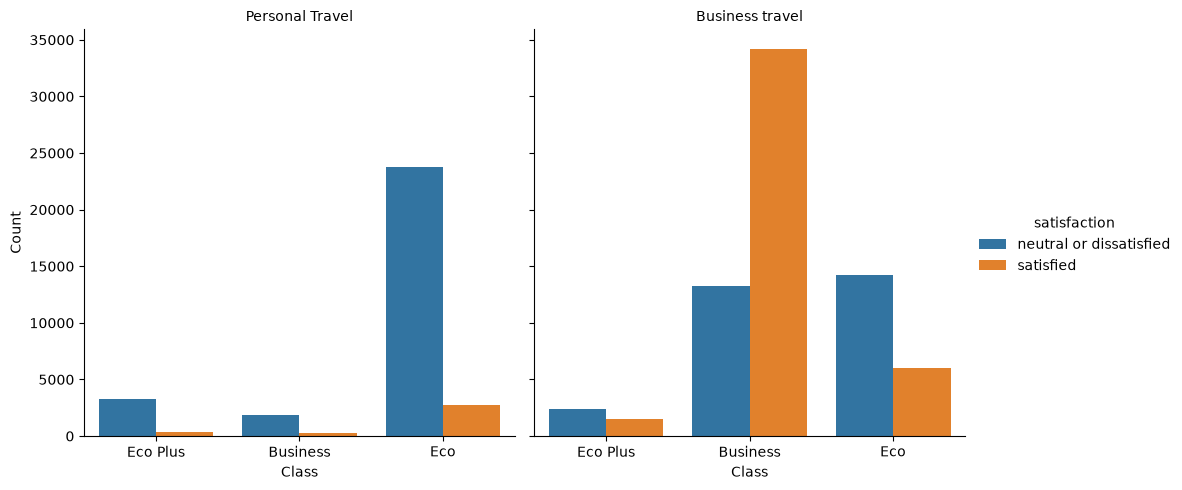

In [32]:
combi = sns.catplot(
    data=train_df,
    x="Class",
    hue="satisfaction",
    col="Type of Travel",
    kind="count",
    height=5,
    aspect=1
)

combi.set_axis_labels("Class", "Count")
combi.set_titles("{col_name}")
plt.show()

## 3. Service

In [34]:
service_cols = ["Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness"]

In [35]:
train_df[service_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Inflight wifi service,103904.0,2.729683,1.327829,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,103904.0,3.060296,1.525075,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,103904.0,2.756901,1.398929,0.0,2.0,3.0,4.0,5.0
Gate location,103904.0,2.976883,1.277621,0.0,2.0,3.0,4.0,5.0
Food and drink,103904.0,3.202129,1.329533,0.0,2.0,3.0,4.0,5.0
Online boarding,103904.0,3.250375,1.349509,0.0,2.0,3.0,4.0,5.0
Seat comfort,103904.0,3.439396,1.319088,0.0,2.0,4.0,5.0,5.0
Inflight entertainment,103904.0,3.358158,1.332991,0.0,2.0,4.0,4.0,5.0
On-board service,103904.0,3.382363,1.288354,0.0,2.0,4.0,4.0,5.0
Leg room service,103904.0,3.351055,1.315605,0.0,2.0,4.0,4.0,5.0


Các giá trị scale ở đây bắt đầu từ 1 - 5 với 1 là rất tệ và 5 là rất tốt

Min = 0 mang ý nghĩa not applicable (không đánh giá)

In [37]:
service_mean = (
    train_df[service_cols]
    .mean()
    .sort_values(ascending=False))

service_mean

Inflight service                     3.640428
Baggage handling                     3.631833
Seat comfort                         3.439396
On-board service                     3.382363
Inflight entertainment               3.358158
Leg room service                     3.351055
Checkin service                      3.304290
Cleanliness                          3.286351
Online boarding                      3.250375
Food and drink                       3.202129
Departure/Arrival time convenient    3.060296
Gate location                        2.976883
Ease of Online booking               2.756901
Inflight wifi service                2.729683
dtype: float64

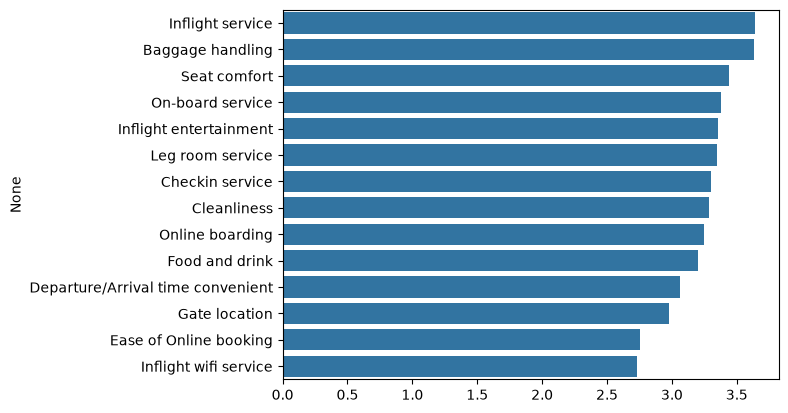

In [38]:
sns.barplot(
    x=service_mean.values,
    y=service_mean.index)
plt.show()

Nếu có thời gian ở đây nên loại giá trị 0 trước khi tính mean

1. Được đánh giá cao nhất: Inflight service và Baggage handling (~3.6/5) hành khách nhìn chung đánh giá khá tích cực về dịch vụ trên chuyến bay và xử lý hành lý.

2. Nhóm khá tốt: Seat comfort, On-board service, Inflight entertainment, Leg room service (~3.3–3.4)  trải nghiệm trực tiếp trên máy bay tương đối ổn.

Được đánh giá thấp nhất: Inflight wifi service và Ease of Online booking (~2.7) trải nghiệm số/digital services có vẻ là điểm yếu và có tiềm năng cải thiện.
Nhìn tổng thể, hầu hết dịch vụ chỉ nằm khoảng 3–3.6/5, tức mức trung bình đến khá, chưa có dịch vụ nào đạt mức đánh giá rất cao.

### 3.1 Online boarding by sat

In [40]:
online_boarding_rate = (
    train_df.groupby("Online boarding")["satisfaction"]
    .apply(lambda x: (x == "satisfied").mean() * 100))

online_boarding_rate

Online boarding
0    55.642504
1    13.776655
2    11.533847
3    13.570904
4    62.304141
5    87.177135
Name: satisfaction, dtype: float64

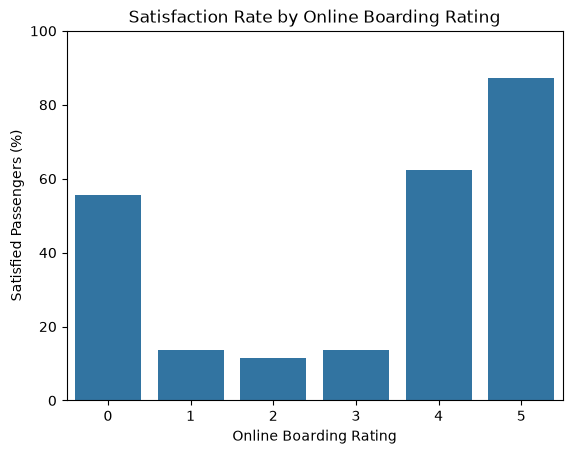

In [41]:
sns.barplot(
    x=online_boarding_rate.index,
    y=online_boarding_rate.values)

plt.title("Satisfaction Rate by Online Boarding Rating")
plt.xlabel("Online Boarding Rating")
plt.ylabel("Satisfied Passengers (%)")

plt.ylim(0, 100)
plt.show()

In [44]:
eda_df["satisfaction"].head()

0    0
1    0
2    1
3    0
4    1
Name: satisfaction, dtype: int64

In [45]:
service_corr = (
    eda_df[service_cols + ["satisfaction"]]
    .corr()["satisfaction"]
    .drop("satisfaction")
    .sort_values(ascending=False))

service_corr

Online boarding                      0.503557
Inflight entertainment               0.398059
Seat comfort                         0.349459
On-board service                     0.322383
Leg room service                     0.313131
Cleanliness                          0.305198
Inflight wifi service                0.284245
Baggage handling                     0.247749
Inflight service                     0.244741
Checkin service                      0.236174
Food and drink                       0.209936
Ease of Online booking               0.171705
Gate location                        0.000682
Departure/Arrival time convenient   -0.051601
Name: satisfaction, dtype: float64

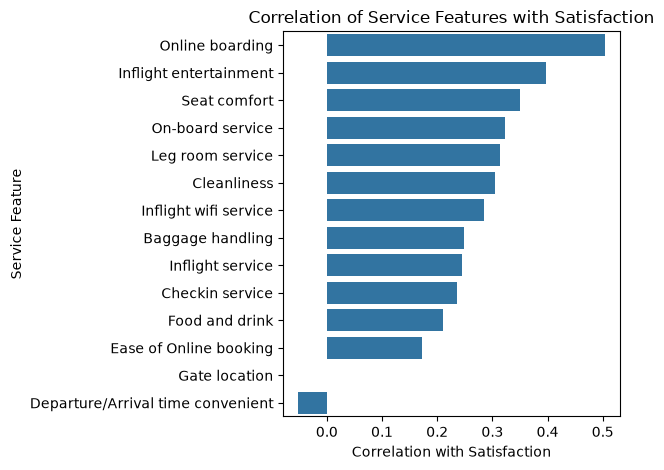

In [46]:
sns.barplot(
    x=service_corr.values,
    y=service_corr.index
)

plt.title("Correlation of Service Features with Satisfaction")
plt.xlabel("Correlation with Satisfaction")
plt.ylabel("Service Feature")

plt.tight_layout()
plt.show()

1. Online boarding nổi bật nhất với correlation khoảng 0.50 → trong các service features, đây là yếu tố có association mạnh nhất với satisfaction.

2. Nhóm tiếp theo gồm Inflight entertainment (~0.40), Seat comfort (~0.35), On-board service và Leg room service (~0.31–0.32) trải nghiệm trực tiếp trên chuyến bay có liên hệ khá rõ với satisfaction.

3. Wifi chỉ ở mức trung bình (~0.29). Điều này rất hay: lúc trước Wi-Fi có mean rating thấp, nhưng không có nghĩa nó là yếu tố liên hệ mạnh nhất với overall satisfaction.

4. Departure/Arrival time convenient gần như không correlation, còn Gate location cũng rất thấp ít signal hơn so với các service khác trong phân tích đơn biến này.